# Dimensionality Reduction in Chemistry (PCA, t-SNE, UMAP)



In [1]:
!pip install -q rdkit umap-learn

In [2]:
import numpy as np

## A1. PCA on two descriptors

Four molecules are described by two descriptors measured on the same scale, $(x_1, x_2)$:

$P = (7, 3), \quad Q = (1, 1), \quad R = (5, 3), \quad S = (3, 1)$

**(a)** Center the data and compute the covariance matrix using $1/N$ normalization.

**(b)** Find both eigenvalues and the corresponding unit eigenvectors. Verify that the eigenvalues sum to the trace of the covariance matrix.

**(c)** What fraction of the total variance is explained by PC1? What angle does PC1 make with the $x_1$ axis?

**(d)** Compute the PC1 scores of all four molecules. Show that the mean squared reconstruction error, when only PC1 is kept, equals the discarded eigenvalue.

**Your answer:**



In [9]:
import numpy as np

# Data: P, Q, R, S
X = np.array([[7, 3], [1, 1], [5, 3], [3, 1]], dtype=float)
N = len(X)

# (a) Center and compute covariance with 1/N normalization
Xc = X - X.mean(axis=0)
C = (Xc.T @ Xc) / N
print("Centered data:\n", Xc)
print("Covariance:\n", C)

# (b) Eigen-decomposition (eigh returns ascending order, so reverse it)
vals, vecs = np.linalg.eigh(C)
vals, vecs = vals[::-1], vecs[:, ::-1]
print("Eigenvalues:", vals)
print("Sum of eigenvalues:", vals.sum(), "| Trace:", np.trace(C))
print("Unit eigenvectors (columns):\n", vecs)

# (c) Variance explained and PC1 angle
print("PC1 variance fraction:", vals[0] / vals.sum())
pc1 = vecs[:, 0]
print("PC1 angle (deg):", np.degrees(np.arctan2(pc1[1], pc1[0])) % 180)

# (d) PC1 scores and reconstruction error
scores = Xc @ pc1
print("PC1 scores:", scores)
print("Mean of scores:", scores.mean(), "| Variance:", scores.var())

Xrec = np.outer(scores, pc1)            # reconstruct using PC1 only
mse = np.mean(np.sum((Xc - Xrec) ** 2, axis=1))
print("Mean squared reconstruction error:", mse, "| Discarded eigenvalue:", vals[1])

Centered data:
 [[ 3.  1.]
 [-3. -1.]
 [ 1.  1.]
 [-1. -1.]]
Covariance:
 [[5. 2.]
 [2. 1.]]
Eigenvalues: [5.82842712 0.17157288]
Sum of eigenvalues: 6.0 | Trace: 6.0
Unit eigenvectors (columns):
 [[-0.92387953  0.38268343]
 [-0.38268343 -0.92387953]]
PC1 variance fraction: 0.9714045207910317
PC1 angle (deg): 22.5
PC1 scores: [-3.15432203  3.15432203 -1.30656296  1.30656296]
Mean of scores: 0.0 | Variance: 5.828427124746188
Mean squared reconstruction error: 0.17157287525380993 | Discarded eigenvalue: 0.17157287525380993


## A2. t-SNE conditional probabilities

A molecule $i$ has three neighbors at distances 1, 1, and 2 in descriptor space. Use

$$p_{j|i} = \frac{\exp(-d_{ij}^2 / 2\sigma_i^2)}{\sum_k \exp(-d_{ik}^2 / 2\sigma_i^2)}$$

**(a)** Compute all three $p_{j|i}$ for $\sigma_i = 1$.

**(b)** Compute the entropy $H = -\sum_j p_{j|i} \log_2 p_{j|i}$ (in bits) and the perplexity $\text{Perp} = 2^H$.

**(c)** For a dataset of $N = 10$ molecules, t-SNE symmetrizes the probabilities as $p_{ij} = (p_{j|i} + p_{i|j}) / 2N$. If $p_{j|i} = 0.45$ and $p_{i|j} = 0.25$, compute $p_{ij}$. Why is symmetrization needed?

**Your answer:**



In [12]:
import numpy as np

# Distances from molecule i to its three neighbors
d = np.array([1.0, 1.0, 2.0])
sigma = 1.0

# (a) Conditional probabilities p_{j|i}
w = np.exp(-d**2 / (2 * sigma**2))
p = w / w.sum()
print("p_{j|i}:", p, "| sum:", p.sum())

# (b) Entropy in bits and perplexity
H = -np.sum(p * np.log2(p))
perp = 2 ** H
print("Entropy H (bits):", H)
print("Perplexity:", perp)

# (c) Symmetrized probability for N = 10
N = 10
p_j_given_i = 0.45
p_i_given_j = 0.25
p_ij = (p_j_given_i + p_i_given_j) / (2 * N)
print("p_ij:", p_ij)

p_{j|i}: [0.44981622 0.44981622 0.10036756] | sum: 0.9999999999999999
Entropy H (bits): 1.369792099709465
Perplexity: 2.5843332178089606
p_ij: 0.034999999999999996


## A3. Heavy tails

**(a)** At what map distance $d$ does the Student-t kernel $(1 + d^2)^{-1}$ fall to 10% of its value at $d = 0$?

**(b)** Answer the same question for the Gaussian kernel $\exp(-d^2)$.

**(c)** In one or two sentences, relate your answers to the crowding problem.

**Your answer:**



In [15]:
import numpy as np

# (a) Student-t: 1 / (1 + d^2) = 0.1
d_t = np.sqrt(1 / 0.1 - 1)
print("Student-t d:", d_t)                      # 3.0

# (b) Gaussian: exp(-d^2) = 0.1
d_g = np.sqrt(-np.log(0.1))
print("Gaussian d:", d_g)                       # ~1.5174

# Sanity check: both kernels at those distances
print(1 / (1 + d_t**2), np.exp(-d_g**2))        # both 0.1

# Compare the tails at a larger distance
d = 4
print("Student-t at d=4:", 1 / (1 + d**2))      # ~0.0588
print("Gaussian at d=4:", np.exp(-d**2))        # ~1.1e-7

Student-t d: 3.0
Gaussian d: 1.5174271293851462
0.1 0.10000000000000002
Student-t at d=4: 0.058823529411764705
Gaussian at d=4: 1.1253517471925912e-07


## A4. UMAP fuzzy weights

For molecule $i$ with $k = 4$ nearest neighbors at distances 0.5, 1.0, 1.5, and 2.0, UMAP uses

$$w_{ij} = \exp\left(-\frac{d_{ij} - \rho_i}{\sigma_i}\right), \qquad \sum_j w_{ij} = \log_2 k$$

where $\rho_i$ is the distance to the nearest neighbor.

**(a)** Show that the normalization condition reduces to $x + x^2 + x^3 = 1$, where $x = \exp(-0.5/\sigma_i)$.

**(b)** Solve for $x$ numerically (for example by bisection) and find $\sigma_i$.

**(c)** If the weight from $i$ to its second neighbor is $w_{ij}$ and the reverse weight is $w_{ji} = 0.5$, compute the symmetrized weight using the fuzzy union $w = a + b - ab$.

**Your answer:**



In [18]:
import numpy as np

# (a)-(b) Solve x + x^2 + x^3 = 1 by bisection
f = lambda x: x + x**2 + x**3 - 1
lo, hi = 0.0, 1.0
for _ in range(60):
    mid = (lo + hi) / 2
    if f(lo) * f(mid) <= 0:
        hi = mid
    else:
        lo = mid
x = (lo + hi) / 2
sigma = -0.5 / np.log(x)
print("x:", x)
print("sigma_i:", sigma)

# Verify against the original definition
d = np.array([0.5, 1.0, 1.5, 2.0])
rho = d.min()
w = np.exp(-(d - rho) / sigma)
print("weights:", w, "| sum:", w.sum(), "| log2(k):", np.log2(4))

# (c) Fuzzy union symmetrization
a = w[1]        # weight to second neighbor
b = 0.5         # reverse weight
print("symmetrized:", a + b - a * b)

x: 0.5436890126920764
sigma_i: 0.8205089649642442
weights: [1.         0.54368901 0.29559774 0.16071324] | sum: 2.0 | log2(k): 2.0
symmetrized: 0.7718445063460382


---
# Part B: Computational practice

The code below builds a dataset of about 90 small molecules in six chemical classes, computes 11 RDKit descriptors, and applies PCA, t-SNE, and UMAP. Run every cell in order, then answer the questions in the answer cells that follow them.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
except ImportError:
    raise ImportError("RDKit is missing. Install it with:  pip install rdkit")

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False
    print("umap-learn not found; UMAP cells will be skipped. Install with: pip install umap-learn")

SEED = 42

## 1. Build a small molecule dataset
Six chemical classes, generated systematically so every SMILES is valid.

In [23]:
def build_dataset():
    rows = []

    def add(smiles, cls):
        rows.append({"smiles": smiles, "class": cls})

    for n in range(1, 11):
        add("C" * n + "O", "Alcohol")
    for m in range(1, 6):
        add("CC(O)" + "C" * m, "Alcohol")

    for n in range(1, 11):
        add("C" * n + "N", "Amine")
    for m in range(1, 6):
        add("CN(C)" + "C" * m, "Amine")

    for n in range(0, 10):
        add("C" * n + "C(=O)O", "Carboxylic acid")
    for m in range(1, 6):
        add("OC(=O)" + "C" * m + "C(=O)O", "Carboxylic acid")

    for n in range(1, 11):
        add("CC(=O)" + "C" * n, "Ketone")

    for n in range(1, 9):
        add("C" * n + "Cl", "Haloalkane")
    for n in range(1, 8):
        add("C" * n + "Br", "Haloalkane")

    for n in range(0, 10):
        add("c1ccccc1" + "C" * n, "Aromatic")
    for s in ["Cc1ccc(C)cc1", "Cc1cccc(C)c1", "c1ccc2ccccc2c1",
              "c1ccc(cc1)-c1ccccc1", "c1ccc2cc3ccccc3cc2c1"]:
        add(s, "Aromatic")

    return pd.DataFrame(rows)


def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "MolMR": Crippen.MolMR(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotBonds": Descriptors.NumRotatableBonds(mol),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "AromRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FracCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
    }


df = build_dataset()
desc = pd.DataFrame([compute_descriptors(s) for s in df["smiles"]])
data = pd.concat([df, desc], axis=1)
feature_cols = list(desc.columns)
X_raw = data[feature_cols].to_numpy(dtype=float)

print(f"{len(data)} molecules, {len(feature_cols)} descriptors")
print(data["class"].value_counts())
data.head()

85 molecules, 11 descriptors
class
Alcohol            15
Amine              15
Carboxylic acid    15
Haloalkane         15
Aromatic           15
Ketone             10
Name: count, dtype: int64


,smiles,class,MolWt,LogP,MolMR,TPSA,HBD,HBA,RotBonds,Rings,AromRings,FracCSP3,HeavyAtoms
0,CO,Alcohol,32.042,-0.3915,8.1428,20.23,1,1,0,0,0,1.0,2
1,CCO,Alcohol,46.069,-0.0014,12.7598,20.23,1,1,0,0,0,1.0,3
2,CCCO,Alcohol,60.096,0.3887,17.3768,20.23,1,1,1,0,0,1.0,4
3,CCCCO,Alcohol,74.123,0.7788,21.9938,20.23,1,1,2,0,0,1.0,5
4,CCCCCO,Alcohol,88.150,1.1689,26.6108,20.23,1,1,3,0,0,1.0,6


## 2. Plotting helper

In [24]:
CLASSES = sorted(data["class"].unique())


STYLES = {
    cls: {"marker": mk, "color": col}
    for cls, mk, col in zip(
        CLASSES,
        ["o", "s", "^", "D", "X", "h"],
        ["#0b7285", "#d9480f", "#5f3dc4", "#2f9e44", "#c2255c", "#f08c00"],
    )
}


def _style_axes(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)


def plot_by_class(ax, Y, title, xlabel="Dim 1", ylabel="Dim 2"):
    labels = data["class"].to_numpy()
    for cls in CLASSES:
        mask = labels == cls
        ax.scatter(
            Y[mask, 0], Y[mask, 1],
            marker=STYLES[cls]["marker"], color=STYLES[cls]["color"],
            s=40, alpha=0.9, edgecolor="black", linewidth=0.4, label=cls,
        )
    _style_axes(ax, title, xlabel, ylabel)


def plot_by_value(ax, Y, values, title, label):
    sc = ax.scatter(
        Y[:, 0], Y[:, 1], c=values, cmap="plasma", s=40,
        edgecolor="black", linewidth=0.4,
    )
    plt.colorbar(sc, ax=ax, label=label)
    _style_axes(ax, title, "Dim 1", "Dim 2")

## 3. PCA: raw vs standardized descriptors

Explained variance ratio (raw):          [0.8178 0.1704 0.0106 0.0011]
Explained variance ratio (standardized): [0.4828 0.2881 0.174  0.0224]


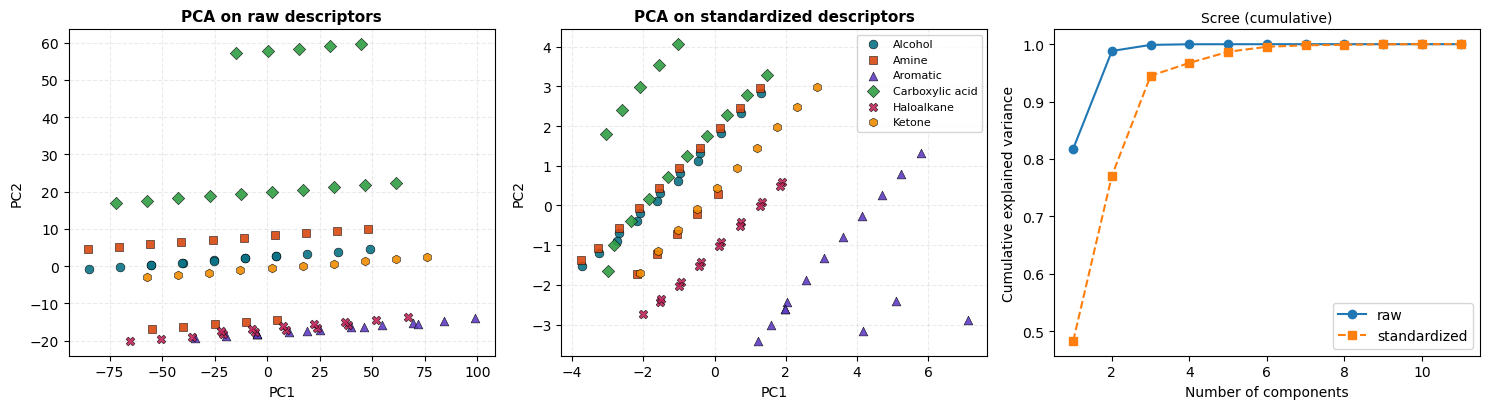

In [25]:
X_std = StandardScaler().fit_transform(X_raw)

pca_raw = PCA().fit(X_raw - X_raw.mean(axis=0))
pca_std = PCA().fit(X_std)

print("Explained variance ratio (raw):         ", np.round(pca_raw.explained_variance_ratio_[:4], 4))
print("Explained variance ratio (standardized):", np.round(pca_std.explained_variance_ratio_[:4], 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
Y_raw = pca_raw.transform(X_raw - X_raw.mean(axis=0))[:, :2]
Y_pca = pca_std.transform(X_std)[:, :2]
plot_by_class(axes[0], Y_raw, "PCA on raw descriptors", "PC1", "PC2")
plot_by_class(axes[1], Y_pca, "PCA on standardized descriptors", "PC1", "PC2")

k = np.arange(1, len(feature_cols) + 1)
axes[2].plot(k, np.cumsum(pca_raw.explained_variance_ratio_), "o-", label="raw")
axes[2].plot(k, np.cumsum(pca_std.explained_variance_ratio_), "s--", label="standardized")
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Cumulative explained variance")
axes[2].set_title("Scree (cumulative)", fontsize=10)
axes[2].legend()
axes[1].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("fig1_pca.png", dpi=150)
plt.show()

### PCA loadings (standardized)

In [26]:
loadings = pd.DataFrame(pca_std.components_[:2].T, index=feature_cols, columns=["PC1", "PC2"])
print(loadings.round(3).sort_values("PC1", key=abs, ascending=False))

              PC1    PC2
LogP        0.404  0.116
MolMR       0.389  0.239
HeavyAtoms  0.355  0.297
MolWt       0.348  0.295
Rings       0.319 -0.246
AromRings   0.319 -0.246
HBA        -0.252  0.360
HBD        -0.231  0.320
TPSA       -0.211  0.360
FracCSP3   -0.195  0.205
RotBonds    0.187  0.480


### YOUR TURN (B1)
1. Why does raw-data PCA give a very high PC1 explained variance? Which descriptor dominates?
2. Using the loadings, give a chemical name to PC1 and PC2 of the standardized PCA.
3. How many components are needed to reach 90% of the variance (standardized)?

**Your answer:**



1.  **What causes the very high PC1 variance in the raw-data PCA, and which descriptor is responsible?**
    Without scaling, PCA favors variables with the biggest numeric values. Descriptors like `MolWt` or `HeavyAtoms` span a much wider range than the rest, so they take over the variance structure. PC1 ends up tracking that single descriptor, which is why its explained variance looks so large.

2.  **What chemical meaning can be assigned to PC1 and PC2 from the standardized loadings?**
    *   **PC1** has strong loadings from `LogP`, `MolMR`, `MolWt`, `HeavyAtoms`, `Rings`, and `AromRings`, so it describes **overall molecular size and lipophilicity**.
    *   **PC2** loads mainly on `RotBonds`, `HBA`, `HBD`, `TPSA`, and `HeavyAtoms`, while `Rings` and `AromRings` pull in the opposite direction. It describes **polarity and flexibility**.

3.  **What is the minimum number of components needed to capture 90% of the variance after standardization?**
    It takes **3 components** to reach the 90% cumulative variance mark.

In [29]:
n90 = int(np.searchsorted(np.cumsum(pca_std.explained_variance_ratio_), 0.90) + 1)
print("Components needed for 90% variance (standardized):", n90)

Components needed for 90% variance (standardized): 3


## 4. t-SNE: effect of perplexity and random seed

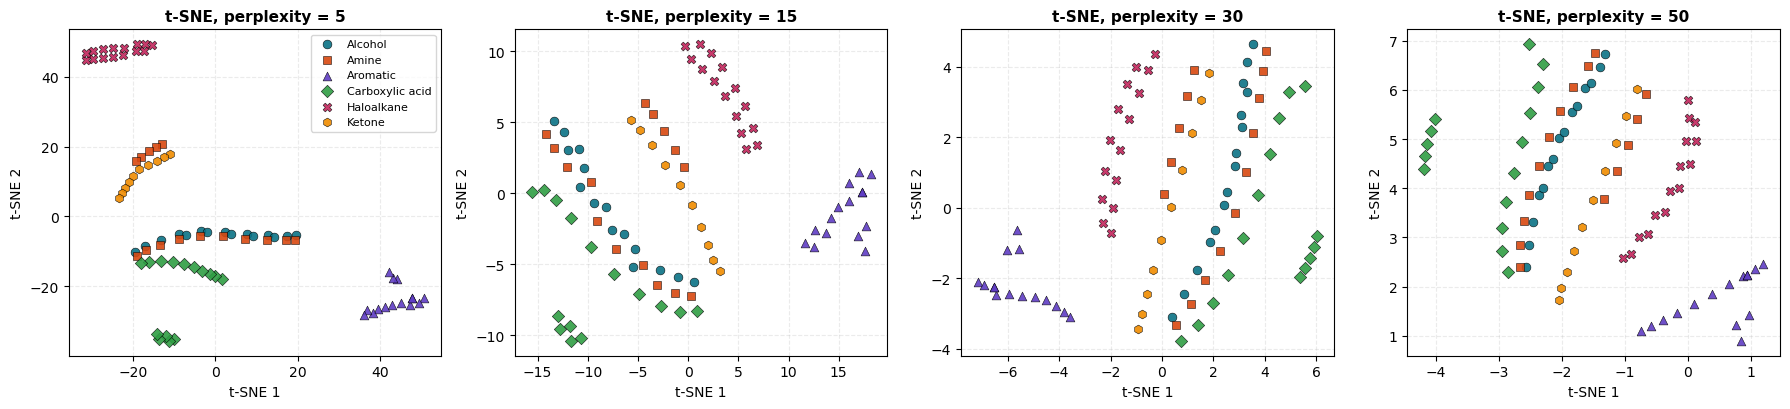

In [31]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 4.2))
tsne_results = {}
for ax, p in zip(axes, perplexities):
    Y = TSNE(n_components=2, perplexity=p, init="pca", learning_rate="auto",
             random_state=SEED).fit_transform(X_std)
    tsne_results[p] = Y
    plot_by_class(ax, Y, f"t-SNE, perplexity = {p}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig2_tsne_perplexity.png", dpi=150)
plt.show()

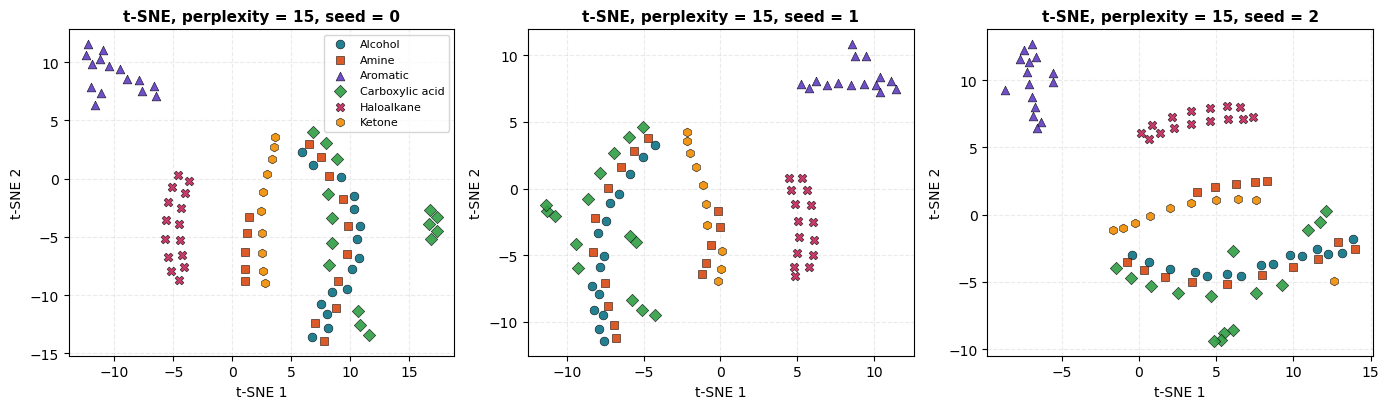

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, seed in zip(axes, [0, 1, 2]):
    Y = TSNE(n_components=2, perplexity=15, init="random", learning_rate="auto",
             random_state=seed).fit_transform(X_std)
    plot_by_class(ax, Y, f"t-SNE, perplexity = 15, seed = {seed}", "t-SNE 1", "t-SNE 2")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig3_tsne_seeds.png", dpi=150)
plt.show()

### YOUR TURN (B2)
1. How does the map change as perplexity increases from 5 to 50?
2. Which features stay the same across seeds, and which change?
3. Why is perplexity = 100 not allowed for this dataset?

**Your answer:**



1.  **What happens to the t-SNE map as perplexity goes from 5 to 50?**
    At low perplexity, t-SNE concentrates on tiny neighborhoods, so the map breaks into small, scattered clusters. As perplexity rises, the algorithm weighs more neighbors at once, and the clusters merge into larger, more coherent groups that better show the overall structure.

2.  **Which features of the map are stable across different seeds, and which vary?**
    The stable part is the grouping itself: molecules of the same chemical class keep ending up together. What changes is the layout, meaning where the clusters sit, how the map is rotated or flipped, and how far apart the clusters appear, since t-SNE starts from a random initialization.

3.  **Why can't perplexity = 100 be used for this dataset?**
    Perplexity has to be smaller than the number of samples. With only 85 molecules, a value of 100 asks for more effective neighbors than the dataset contains, so the method cannot be run with that setting.

## 5. UMAP: effect of n_neighbors and min_dist

c:\Users\Hi\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Hi\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Hi\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Hi\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


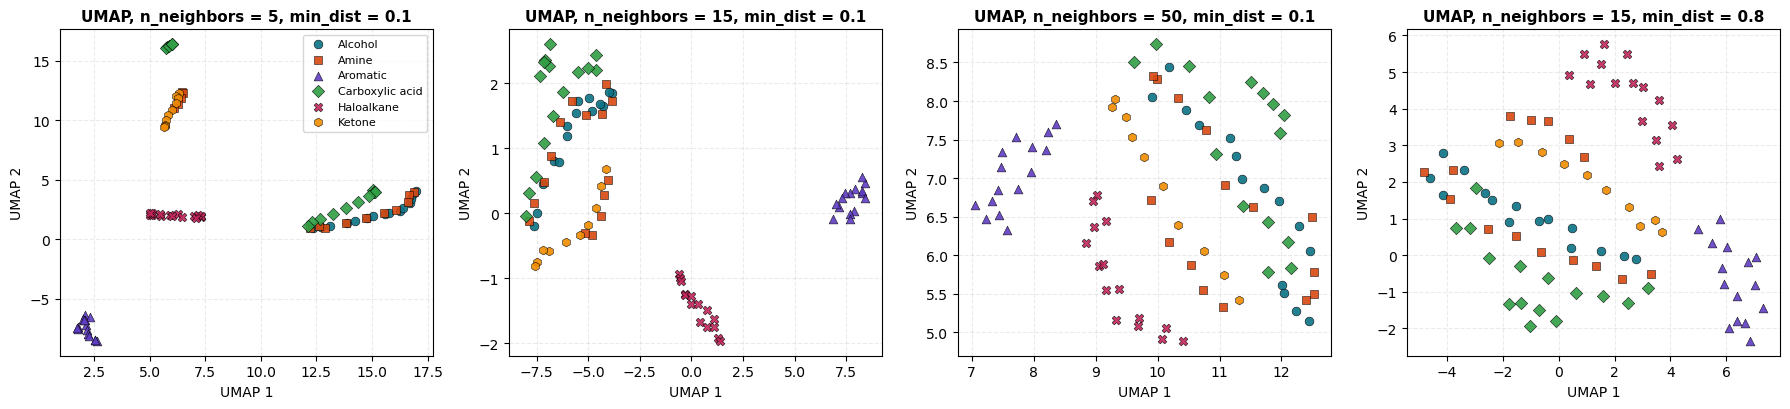

In [34]:
umap_results = {}
if HAVE_UMAP:
    settings = [(5, 0.1), (15, 0.1), (50, 0.1), (15, 0.8)]
    fig, axes = plt.subplots(1, len(settings), figsize=(18, 4.2))
    for ax, (nn, md) in zip(axes, settings):
        Y = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=SEED).fit_transform(X_std)
        umap_results[(nn, md)] = Y
        plot_by_class(ax, Y, f"UMAP, n_neighbors = {nn}, min_dist = {md}", "UMAP 1", "UMAP 2")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("fig4_umap.png", dpi=150)
    plt.show()

### YOUR TURN (B3)
1. Compare n_neighbors = 5 and 50. Which shows more local detail, which more global layout?
2. What does increasing min_dist from 0.1 to 0.8 do to the clusters?

**Your answer:**



1.  **How do n_neighbors = 5 and n_neighbors = 50 differ, and which one preserves more local detail versus global layout?**
    *   **`n_neighbors = 5`** makes UMAP look at very small neighborhoods, so it preserves **local detail**. The result is many tight clusters that reveal fine substructure.
    *   **`n_neighbors = 50`** makes UMAP consider a much wider neighborhood, so it preserves the **global layout**. The clusters are smoother and better separated, and they reflect the overall structure of the data.

2.  **What effect does raising min_dist from 0.1 to 0.8 have on the clusters?**
    A larger `min_dist` stops points from sitting close together in the embedding, so the clusters become **looser and more spread out**. With `min_dist = 0.1`, points can pack into dense, compact clumps, while at `0.8` they are pushed apart and the clusters look more diffuse.

## 6. Colour by a continuous property

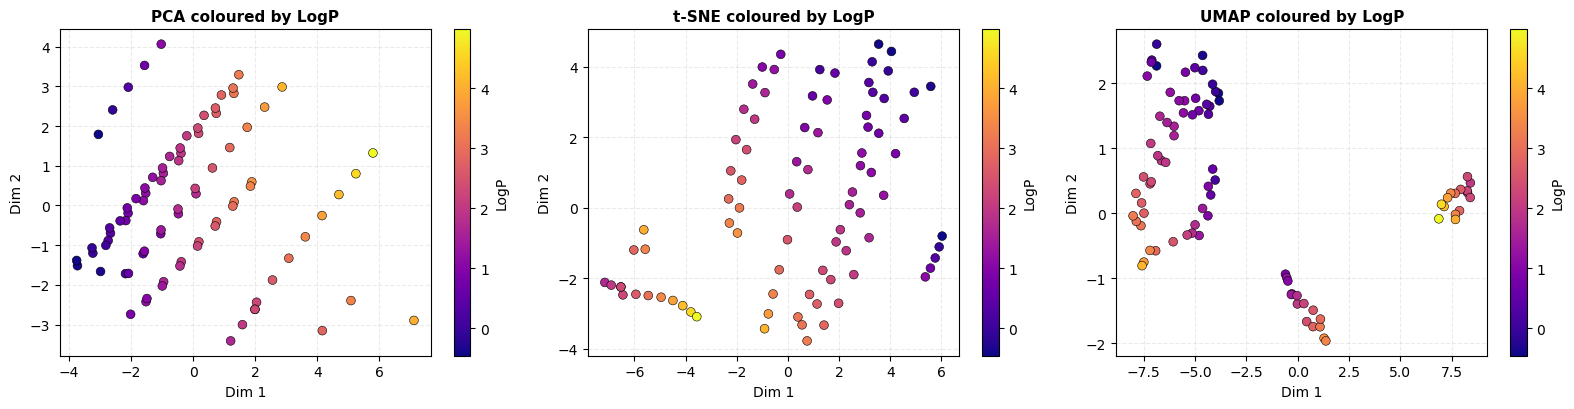

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_by_value(axes[0], Y_pca, data["LogP"], "PCA coloured by LogP", "LogP")
plot_by_value(axes[1], tsne_results[30], data["LogP"], "t-SNE coloured by LogP", "LogP")
if HAVE_UMAP:
    plot_by_value(axes[2], umap_results[(15, 0.1)], data["LogP"], "UMAP coloured by LogP", "LogP")
else:
    axes[2].axis("off")
plt.tight_layout()
plt.savefig("fig5_logp.png", dpi=150)
plt.show()

### YOUR TURN (B4)
Inside each class cluster, is there a smooth LogP gradient? What structural change
(hint: chain length) produces it?

**Your answer:**



Inside each class cluster, LogP tends to change **gradually and smoothly** from one end to the other. The main driver is **chain length**. In a homologous series such as the alcohols, every extra carbon raises both molecular weight and lipophilicity, so molecules with similar chain lengths end up with similar LogP values and sit next to each other along the gradient.

## 7. Quantitative comparison: trustworthiness
Trustworthiness (0 to 1) measures how well each point's nearest neighbours in the map
were also neighbours in the original space. 1 means perfect local preservation.

In [36]:
emb = {"PCA (2 PCs)": Y_pca, "t-SNE (perp 30)": tsne_results[30]}
if HAVE_UMAP:
    emb["UMAP (nn 15)"] = umap_results[(15, 0.1)]

for k_nn in [5, 15]:
    for name, Y in emb.items():
        t = trustworthiness(X_std, Y, n_neighbors=k_nn)
        print(f"k = {k_nn:2d}  {name:18s} trustworthiness = {t:.3f}")

k =  5  PCA (2 PCs)        trustworthiness = 0.986
k =  5  t-SNE (perp 30)    trustworthiness = 0.996
k =  5  UMAP (nn 15)       trustworthiness = 0.991
k = 15  PCA (2 PCs)        trustworthiness = 0.981
k = 15  t-SNE (perp 30)    trustworthiness = 0.971
k = 15  UMAP (nn 15)       trustworthiness = 0.932


### YOUR TURN (B5)
1. Which method preserves local neighbourhoods best? Is that what you expected?
2. Trustworthiness says nothing about distances between clusters. Propose a check
   for global structure (hint: correlate pairwise distances in the original and 2D spaces).

1.  **Which method preserves local neighbourhoods best? Is that what you expected?**
    Based on trustworthiness scores, **t-SNE** generally preserves local neighborhoods best, especially for smaller `k` values. This is expected as t-SNE is designed for local structure preservation.

2.  **Trustworthiness says nothing about distances between clusters. Propose a check for global structure (hint: correlate pairwise distances in the original and 2D spaces).**
    To check global structure, we can compute the **Spearman rank-order correlation coefficient** between pairwise distances in the original high-dimensional space and the low-dimensional embedding. A higher correlation (closer to 1) indicates better global structure preservation.

**Your answer:**


In [37]:
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

# Requires X_std, Y_pca, tsne_results, umap_results and HAVE_UMAP from earlier cells
dist_original = pdist(X_std, metric="euclidean")

embeddings = {
    "PCA": Y_pca,
    "t-SNE": tsne_results[30],
}
if HAVE_UMAP:
    embeddings["UMAP"] = umap_results[(15, 0.1)]

print("Spearman correlation of pairwise distances (original vs embedding):")
for name, coords in embeddings.items():
    rho, _ = spearmanr(dist_original, pdist(coords, metric="euclidean"))
    print(f"  {name:<6}: {rho:.3f}")

if not HAVE_UMAP:
    print("  UMAP not available, skipped.")

print("\nHigher rho = better preservation of global structure (rank order of distances).")

Spearman correlation of pairwise distances (original vs embedding):
  PCA   : 0.954
  t-SNE : 0.866
  UMAP  : 0.697

Higher rho = better preservation of global structure (rank order of distances).
